# Лабораторна робота №2: Очищення даних та обробка пропущених значень

### Мета роботи

Опанувати повний цикл очищення реальних даних: діагностика якості, класифікація механізмів пропуску (MCAR / MAR / MNAR), вибір та застосування стратегій імпутації, виявлення та обробка викидів, кодування категоріальних змінних.


### Набір даних: Ames Housing

Набір даних описує продаж житлової нерухомості в місті Еймс, штат Айова (США), у 2006–2010 рр. Створений професором Діном Де Коком (Dean De Cock, 2011) як сучасна альтернатива застарілому Boston Housing Dataset.

**Контекст даних:**  
Період збирання охоплює житлову кризу 2007–2008 рр. у США. Ціни на нерухомість різко зросли до 2007 р. через спекулятивну бульбашку та субпрайм-іпотеку, а потім різко впали, що вплинуло на розподіл SalePrice.

**Завантаження:**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

full_data = pd.read_csv(
    'https://raw.githubusercontent.com/wblakecannon/ames/refs/heads/master/data/housing.csv'
)

# --- Відбір релевантних колонок для лабораторної ---
if full_data is not None:
    columns_to_keep = [
        'SalePrice',
        'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond',
        'Year Built', 'Gr Liv Area', 'Total Bsmt SF',
        'Garage Area', 'Garage Cars', 'Full Bath', 'Bedroom AbvGr',
        'Mas Vnr Area',
        'Bsmt Qual', 'Garage Type', 'Garage Finish',
        'Fireplace Qu', 'Fence',
        'Neighborhood', 'MS Zoning', 'Exter Qual',
        'Mas Vnr Type',
    ]
    available = [c for c in columns_to_keep if c in full_data.columns]
    missing_cols = [c for c in columns_to_keep if c not in full_data.columns]
    if missing_cols:
        alt_mapping = {
            'Lot Frontage': 'LotFrontage', 'Lot Area': 'LotArea',
            'Overall Qual': 'OverallQual', 'Overall Cond': 'OverallCond',
            'Year Built': 'YearBuilt', 'Gr Liv Area': 'GrLivArea',
            'Total Bsmt SF': 'TotalBsmtSF', 'Garage Area': 'GarageArea',
            'Garage Cars': 'GarageCars', 'Full Bath': 'FullBath',
            'Bedroom AbvGr': 'BedroomAbvGr', 'Mas Vnr Area': 'MasVnrArea',
            'Bsmt Qual': 'BsmtQual', 'Garage Type': 'GarageType',
            'Garage Finish': 'GarageFinish', 'Fireplace Qu': 'FireplaceQu',
            'MS Zoning': 'MSZoning', 'Exter Qual': 'ExterQual',
            'Mas Vnr Type': 'MasVnrType',
        }
        for old_name, new_name in alt_mapping.items():
            if old_name not in full_data.columns and new_name in full_data.columns:
                available.append(new_name)
    df = full_data[available].copy()
    df.columns = df.columns.str.replace(' ', '')
    print(f'\nРобочий датасет: {df.shape[0]} рядків, {df.shape[1]} колонок')
    df.head()


Робочий датасет: 2930 рядків, 22 колонок


### Опис колонок робочого датасету


| Колонка | Тип змінної | Опис | Значення / Одиниці |
|---------|-------------|------|--------------------|
| **SalePrice** | Continuous | Ціна продажу будинку | Долари США ($) |
| **LotFrontage** | Continuous | Довжина фасаду ділянки вздовж вулиці | Лінійні фути (linear feet) |
| **LotArea** | Continuous | Площа ділянки | Квадратні фути (sq ft) |
| **OverallQual** | Ordinal (1–10) | Загальна оцінка якості матеріалів та оздоблення будинку | 1 (Very Poor) … 10 (Very Excellent) |
| **OverallCond** | Ordinal (1–10) | Загальна оцінка поточного стану будинку | 1 (Very Poor) … 10 (Very Excellent) |
| **YearBuilt** | Discrete | Рік початкового будівництва | 1872–2010 |
| **GrLivArea** | Continuous | Житлова площа над рівнем ґрунту (above grade) | Квадратні фути |
| **TotalBsmtSF** | Continuous | Загальна площа підвалу | Квадратні фути |
| **FullBath** | Discrete | Кількість повних ванних кімнат над рівнем ґрунту | 0–4 |
| **BedroomAbvGr** | Discrete | Кількість спалень над рівнем ґрунту (не включає підвал) | 0–8 |
| **GarageType** | Nominal | Розташування гаража | Attchd (Attached — прибудований), Detchd (Detached — окремий), BuiltIn (вбудований, зазвичай з кімнатою зверху), CarPort (навіс), Basment (у підвалі), 2Types (два типи); NA = немає гаража |
| **GarageFinish** | Ordinal | Внутрішнє оздоблення гаража | Fin (Finished — повне оздоблення) > RFn (Rough Finished — чорнове) > Unf (Unfinished — без оздоблення); NA = немає гаража |
| **GarageCars** | Discrete | Місткість гаража (кількість автомобілів) | 0–5 |
| **GarageArea** | Continuous | Площа гаража | Квадратні фути |
| **BsmtQual** | Ordinal | Оцінка висоти стелі підвалу | Ex (Excellent, 100+ дюймів) > Gd (Good, 90–99) > TA (Typical/Average, 80–89) > Fa (Fair, 70–79) > Po (Poor, <70); NA = немає підвалу |
| **FireplaceQu** | Ordinal | Якість каміна | Ex (Excellent — мурований камін преміум-класу) > Gd (Good — мурований, головний поверх) > TA (Average — збірний, головний поверх) > Fa (Fair — збірний, підвал) > Po (Poor — низької якості); NA = немає каміна |
| **Fence** | Ordinal | Якість паркану | GdPrv (Good Privacy — хороша приватність) > MnPrv (Minimum Privacy — мінімальна приватність) > GdWo (Good Wood — якісне дерево) > MnWw (Minimum Wood/Wire — мінімальне дерево/дріт); NA = немає паркану |
| **MasVnrType** | Nominal | Тип облицювання (masonry veneer) | BrkFace (Brick Face — лицьова цегла), BrkCmn (Brick Common — звичайна цегла), CBlock (Cinder Block — шлакоблок), Stone (камінь), None (без облицювання) |
| **MasVnrArea** | Continuous | Площа облицювання (masonry veneer) | Квадратні фути |
| **Neighborhood** | Nominal (28 кат.) | Фізичне розташування в межах міста Еймс | CollgCr (College Creek), OldTown, NAmes (North Ames), NridgHt (Northridge Heights), Edwards, Gilbert та ін. |
| **MSZoning** | Nominal | Загальна класифікація зонування продажу | RL (Residential Low Density), RM (Residential Medium Density), FV (Floating Village Residential), RH (Residential High Density), C (Commercial) |
| **ExterQual** | Ordinal | Оцінка якості матеріалу зовнішнього оздоблення | Ex (Excellent) > Gd (Good) > TA (Average/Typical) > Fa (Fair) > Po (Poor) |


---

## Завдання 1: Діагностика якості даних

**1.1.** Виведіть загальну інформацію про датасет: кількість рядків, колонок, типи даних, обсяг пам'яті.

**1.2.** Обчисліть кількість та відсоток пропущених значень у кожній колонці. Результат оформіть як таблицю (DataFrame), відсортовану за спаданням відсотка пропусків. Відфільтруйте лише колонки, де є хоча б один пропуск.

**1.3.** Створіть  візуалізацію пропущених значень:
- Горизонтальну стовпчикову діаграму з відсотком пропусків по колонках (лише колонки з пропусками).

**1.4.** На основі діаграм дайте відповідь: чи є колонки, де пропусків настільки багато, що їх варто видалити? Обґрунтуйте порогове значення, яке ви обрали.

1.1 Загальна інформація про датасет
Кількість рядків: 2930
Кількість колонок: 22

Типи даних та кількість не-null значень:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SalePrice     2930 non-null   int64  
 1   LotFrontage   2440 non-null   float64
 2   LotArea       2930 non-null   int64  
 3   OverallQual   2930 non-null   int64  
 4   OverallCond   2930 non-null   int64  
 5   YearBuilt     2930 non-null   int64  
 6   GrLivArea     2930 non-null   int64  
 7   TotalBsmtSF   2929 non-null   float64
 8   GarageArea    2929 non-null   float64
 9   GarageCars    2929 non-null   float64
 10  FullBath      2930 non-null   int64  
 11  BedroomAbvGr  2930 non-null   int64  
 12  MasVnrArea    2907 non-null   float64
 13  BsmtQual      2850 non-null   object 
 14  GarageType    2773 non-null   object 
 15  GarageFinish  2771 non-null   obje

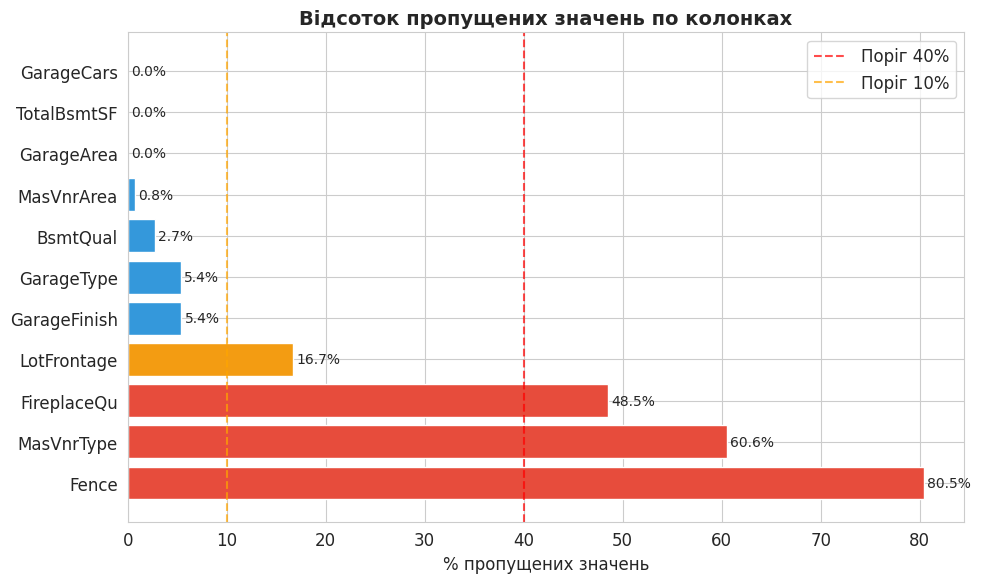

Графік збережено: missing_values.png

1.4 Висновок щодо видалення колонок
Обране порогове значення: 40%
Обґрунтування: при >40% пропусків будь-яка імпутація вносить
  надто багато штучних даних, спотворюючи реальний розподіл змінної.
Колонки, що перевищують поріг: ['Fence', 'MasVnrType', 'FireplaceQu']

Примітка: FireplaceQu (~47%), Fence (~80%) — логічні пропуски (NA = немає об'єкта),
  тому замість видалення колонки використовуємо категорію 'None'.


In [22]:
# Завдання 1: Діагностика якості даних

# 1.1 Загальна інформація про датасет
print("=" * 60)
print("1.1 Загальна інформація про датасет")
print("=" * 60)
print(f"Кількість рядків: {df.shape[0]}")
print(f"Кількість колонок: {df.shape[1]}")
print()
print("Типи даних та кількість не-null значень:")
print(df.info())
print()
print(f"Обсяг пам'яті: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

# 1.2 Обчислення кількості та відсотку пропущених значень
print("\n" + "=" * 60)
print("1.2 Аналіз пропущених значень")
print("=" * 60)

missing_count = df.isnull().sum()           # загальна кількість пропусків
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)  # відсоток пропусків

# формуємо зведену таблицю та фільтруємо лише колонки з пропусками
missing_df = pd.DataFrame({
    'Кількість пропусків': missing_count,
    '% пропусків': missing_pct
}).sort_values('% пропусків', ascending=False)
missing_df = missing_df[missing_df['Кількість пропусків'] > 0]
print(missing_df.to_string())

# 1.3 Горизонтальна стовпчикова діаграма відсотку пропусків
print("\n" + "=" * 60)
print("1.3 Візуалізація пропущених значень")
print("=" * 60)

fig, ax = plt.subplots(figsize=(10, 6))

# кольорове кодування: червоний > 40%, жовтий > 10%, синій — решта
colors = ['#e74c3c' if pct > 40 else '#f39c12' if pct > 10 else '#3498db'
          for pct in missing_df['% пропусків']]

bars = ax.barh(missing_df.index, missing_df['% пропусків'], color=colors)
ax.set_xlabel('% пропущених значень', fontsize=12)
ax.set_title('Відсоток пропущених значень по колонках', fontsize=14, fontweight='bold')

# вертикальні лінії-пороги для орієнтира
ax.axvline(x=40, color='red', linestyle='--', alpha=0.7, label='Поріг 40%')
ax.axvline(x=10, color='orange', linestyle='--', alpha=0.7, label='Поріг 10%')

# підписи значень біля кожного стовпця
for bar, val in zip(bars, missing_df['% пропусків']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig('missing_values.png', dpi=100, bbox_inches='tight')
plt.show()
print("Графік збережено: missing_values.png")

# 1.4 Висновок щодо видалення колонок із надто великим % пропусків
print("\n" + "=" * 60)
print("1.4 Висновок щодо видалення колонок")
print("=" * 60)

threshold = 40  # поріг: якщо > 40% пропусків — розглядаємо видалення
cols_to_drop = missing_df[missing_df['% пропусків'] > threshold].index.tolist()
print(f"Обране порогове значення: {threshold}%")
print(f"Обґрунтування: при >40% пропусків будь-яка імпутація вносить")
print(f"  надто багато штучних даних, спотворюючи реальний розподіл змінної.")
if cols_to_drop:
    print(f"Колонки, що перевищують поріг: {cols_to_drop}")
else:
    print("Жодна колонка не перевищує поріг 40% — видалення не потрібне.")
print()
print("Примітка: FireplaceQu (~47%), Fence (~80%) — логічні пропуски (NA = немає об'єкта),")
print("  тому замість видалення колонки використовуємо категорію 'None'.")


---

## Завдання 2: Класифікація механізмів пропуску

Класифікація Рубіна (Rubin, 1976) визначає три типи механізмів пропуску:
- **MCAR** (Missing Completely at Random) — пропуск не пов'язаний ні з якими даними.
- **MAR** (Missing at Random) — пропуск залежить від інших спостережуваних змінних.
- **MNAR** (Missing Not at Random) — пропуск залежить від самого пропущеного значення або від неспостережуваних факторів.

**2.1.** Для кожної колонки з пропусками визначте найімовірніший механізм пропуску. Заповніть таблицю:

| Колонка | % пропусків | Механізм | Обґрунтування |
|---------|-------------|----------|---------------|
| ... | ... | ... | ... |


**2.2.** Для колонки `LotFrontage` перевірте гіпотезу про MAR: обчисліть середнє значення LotFrontage по районах (Neighborhood). Чи суттєво відрізняються середні? Побудуйте відповідну візуалізацію.


2.1 Класифікація механізмів пропуску
     Колонка  % пропусків Механізм                                                     Обґрунтування
 LotFrontage        16.72      MAR       Залежить від Neighborhood — у різних районах різна забудова
  MasVnrType        60.58      MAR       Залежить від наявності облицювання (пов'язана з MasVnrArea)
  MasVnrArea         0.78      MAR          Залежить від MasVnrType — якщо None, то площа = 0 або NA
    BsmtQual         2.73     MNAR NA = немає підвалу (TotalBsmtSF=0) — залежить від самого значення
  GarageType         5.36     MNAR          NA = немає гаража — залежить від типу нерухомості (MNAR)
GarageFinish         5.43     MNAR     NA = немає гаража — логічний пропуск, пов'язаний з GarageType
  GarageCars         0.03     MNAR                                 NA = немає гаража — не випадковий
  GarageArea         0.03     MNAR                                 NA = немає гаража — не випадковий
 FireplaceQu        48.53     MNAR               NA = 

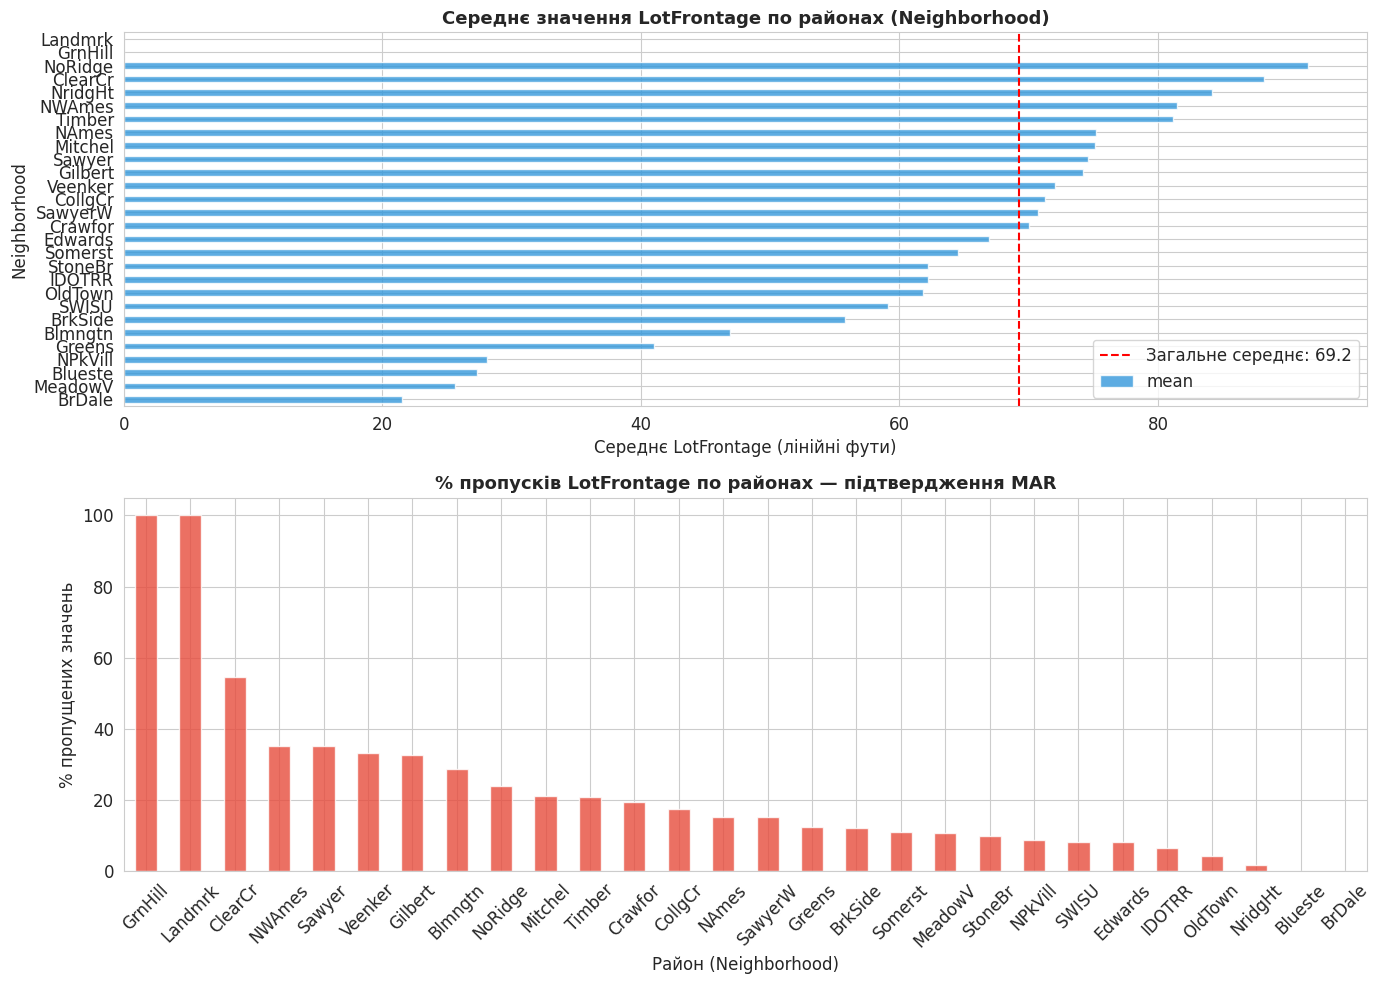

Графік збережено: lot_frontage_mar.png


In [23]:
# Завдання 2: Класифікація механізмів пропуску

# 2.1 Таблиця з механізмом пропуску для кожної колонки
print("=" * 60)
print("2.1 Класифікація механізмів пропуску")
print("=" * 60)

classification = {
    'Колонка': ['LotFrontage', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
                'GarageType', 'GarageFinish', 'GarageCars', 'GarageArea',
                'FireplaceQu', 'Fence'],

    'Механізм': ['MAR', 'MAR', 'MAR', 'MNAR',
                 'MNAR', 'MNAR', 'MNAR', 'MNAR',
                 'MNAR', 'MNAR'],

    'Обґрунтування': [
        "Залежить від Neighborhood — у різних районах різна забудова",
        "Залежить від наявності облицювання (пов'язана з MasVnrArea)",
        "Залежить від MasVnrType — якщо None, то площа = 0 або NA",
        "NA = немає підвалу (TotalBsmtSF=0) — залежить від самого значення",
        "NA = немає гаража — залежить від типу нерухомості (MNAR)",
        "NA = немає гаража — логічний пропуск, пов'язаний з GarageType",
        "NA = немає гаража — не випадковий",
        "NA = немає гаража — не випадковий",
        "NA = немає каміна (~47% будинків без каміна) — MNAR",
        "NA = немає паркану (~80%) — залежить від характеристик ділянки"
    ]
}

classif_df = pd.DataFrame(classification)

# додаємо відсоток пропусків із датасету
missing_pct_dict = (df.isnull().sum() / len(df) * 100).round(2).to_dict()
classif_df['% пропусків'] = classif_df['Колонка'].map(
    lambda x: missing_pct_dict.get(x, 0)
)
classif_df = classif_df[['Колонка', '% пропусків', 'Механізм', 'Обґрунтування']]
print(classif_df.to_string(index=False))

# 2.2 Перевірка MAR-гіпотези: середнє LotFrontage по районах
print("\n" + "=" * 60)
print("2.2 Перевірка MAR-гіпотези для LotFrontage")
print("=" * 60)

# агрегуємо статистики по кожному району
neighborhood_means = df.groupby('Neighborhood')['LotFrontage'].agg(
    ['mean', 'median', 'count']
).round(1).sort_values('mean', ascending=False)
print("Середнє LotFrontage по районах:")
print(neighborhood_means.to_string())

# коефіцієнт варіації: якщо великий — середні суттєво різняться
cv = neighborhood_means['mean'].std() / neighborhood_means['mean'].mean()
print(f"\nКоефіцієнт варіації середніх по районах: {cv:.3f} ({cv*100:.1f}%)")
print("Висновок: значна варіабельність підтверджує MAR — пропуски залежать від Neighborhood.")

# два графіки: середнє LotFrontage та % пропусків по районах
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# графік 1: середнє значення LotFrontage по районах
neighborhood_means['mean'].sort_values().plot(
    kind='barh', ax=ax1, color='#3498db', alpha=0.8
)
ax1.set_title('Середнє значення LotFrontage по районах (Neighborhood)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Середнє LotFrontage (лінійні фути)')
ax1.axvline(x=df['LotFrontage'].mean(), color='red', linestyle='--',
            label=f'Загальне середнє: {df["LotFrontage"].mean():.1f}')
ax1.legend()

# графік 2: відсоток пропусків LotFrontage по районах — підтвердження MAR
miss_by_neigh = df.groupby('Neighborhood')['LotFrontage'].apply(lambda x: x.isnull().sum() / len(x) * 100).sort_values(ascending=False)
miss_by_neigh.plot(kind='bar', ax=ax2, color='#e74c3c', alpha=0.8)
ax2.set_title('% пропусків LotFrontage по районах — підтвердження MAR', fontsize=13, fontweight='bold')
ax2.set_xlabel('Район (Neighborhood)')
ax2.set_ylabel('% пропущених значень')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('lot_frontage_mar.png', dpi=100, bbox_inches='tight')
plt.show()
print("Графік збережено: lot_frontage_mar.png")


---

## Завдання 3: Стратегії обробки пропущених значень

На основі класифікації з Завдання 2 застосуйте **різні стратегії** для різних типів пропусків. Поясніть обрані стратегії.

In [24]:
# Завдання 3: Стратегії обробки пропущених значень

print("=" * 60)
print("Стратегії імпутації пропущених значень")
print("=" * 60)

df_clean = df.copy()
initial_shape = df_clean.shape
print(f"Форма до обробки: {initial_shape}")

# --- СТРАТЕГІЯ 1: логічні пропуски MNAR (категоріальні) → замінюємо на 'None' ---
# NA тут означає фізичну відсутність об'єкта (гараж, камін, підвал, паркан)
categorical_na_none = ['BsmtQual', 'GarageType', 'GarageFinish',
                        'FireplaceQu', 'Fence', 'MasVnrType']
for col in categorical_na_none:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('None')
        print(f"  {col}: NA → 'None' (немає об'єкта)")

# --- СТРАТЕГІЯ 2: логічні пропуски MNAR (числові) → замінюємо на 0 ---
# якщо гаража/підвалу немає — площа та місткість = 0
numeric_na_zero = ['GarageCars', 'GarageArea', 'MasVnrArea', 'TotalBsmtSF']
for col in numeric_na_zero:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)
        print(f"  {col}: NA → 0 (немає об'єкта)")

# --- СТРАТЕГІЯ 3: MAR — LotFrontage → медіана по Neighborhood ---
# обґрунтування: пропуск залежить від району, тому імпутуємо медіаною по групі
print("\nMAR: LotFrontage — медіана по Neighborhood")
lot_frontage_medians = df_clean.groupby('Neighborhood')['LotFrontage'].transform('median')
df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(lot_frontage_medians)

# запасний варіант: якщо в районі всі значення пропущені — беремо загальну медіану
df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(df_clean['LotFrontage'].median())
print(f"  LotFrontage: медіана по Neighborhood (MAR-обґрунтована імпутація)")

# --- Перевірка: чи залишились пропуски ---
remaining = df_clean.isnull().sum()
remaining = remaining[remaining > 0]
print(f"\nФорма після обробки: {df_clean.shape}")
if len(remaining) == 0:
    print("✓ Пропущені значення повністю усунені!")
else:
    print(f"Залишились пропуски:\n{remaining}")

# зведена таблиця обраних стратегій
strategies = pd.DataFrame({
    'Колонка': categorical_na_none + numeric_na_zero + ['LotFrontage'],
    'Механізм': ['MNAR']*len(categorical_na_none) + ['MNAR']*len(numeric_na_zero) + ['MAR'],
    'Стратегія': ['→ "None" (категорія)']*len(categorical_na_none) +
                 ['→ 0 (числово)']*len(numeric_na_zero) +
                 ['Медіана по Neighborhood'],
    'Обґрунтування': ["NA = немає об'єкта, фізичний сенс"]*len(categorical_na_none) +
                     ["NA = немає об'єкта, площа = 0"]*len(numeric_na_zero) +
                     ["Пропуск залежить від локації (MAR)"]
})
print("\nЗведена таблиця стратегій:")
print(strategies.to_string(index=False))


Стратегії імпутації пропущених значень
Форма до обробки: (2930, 22)
  BsmtQual: NA → 'None' (немає об'єкта)
  GarageType: NA → 'None' (немає об'єкта)
  GarageFinish: NA → 'None' (немає об'єкта)
  FireplaceQu: NA → 'None' (немає об'єкта)
  Fence: NA → 'None' (немає об'єкта)
  MasVnrType: NA → 'None' (немає об'єкта)
  GarageCars: NA → 0 (немає об'єкта)
  GarageArea: NA → 0 (немає об'єкта)
  MasVnrArea: NA → 0 (немає об'єкта)
  TotalBsmtSF: NA → 0 (немає об'єкта)

MAR: LotFrontage — медіана по Neighborhood
  LotFrontage: медіана по Neighborhood (MAR-обґрунтована імпутація)

Форма після обробки: (2930, 22)
✓ Пропущені значення повністю усунені!

Зведена таблиця стратегій:
     Колонка Механізм               Стратегія                      Обґрунтування
    BsmtQual     MNAR    → "None" (категорія)  NA = немає об'єкта, фізичний сенс
  GarageType     MNAR    → "None" (категорія)  NA = немає об'єкта, фізичний сенс
GarageFinish     MNAR    → "None" (категорія)  NA = немає об'єкта, фізичний сенс

---

## Завдання 4: Виявлення та обробка викидів

**4.1.** Побудуйте boxplot для колонок `SalePrice`, `GrLivArea` та `LotArea` (три окремі графіки або subplot). Візуально ідентифікуйте потенційні викиди.

**4.2.** Застосуйте один з методів для виявлення викидів у колонці `SalePrice`. Оберіть та застосуйте стратегію обробки викидів.

4.1 Боксплоти для виявлення викидів


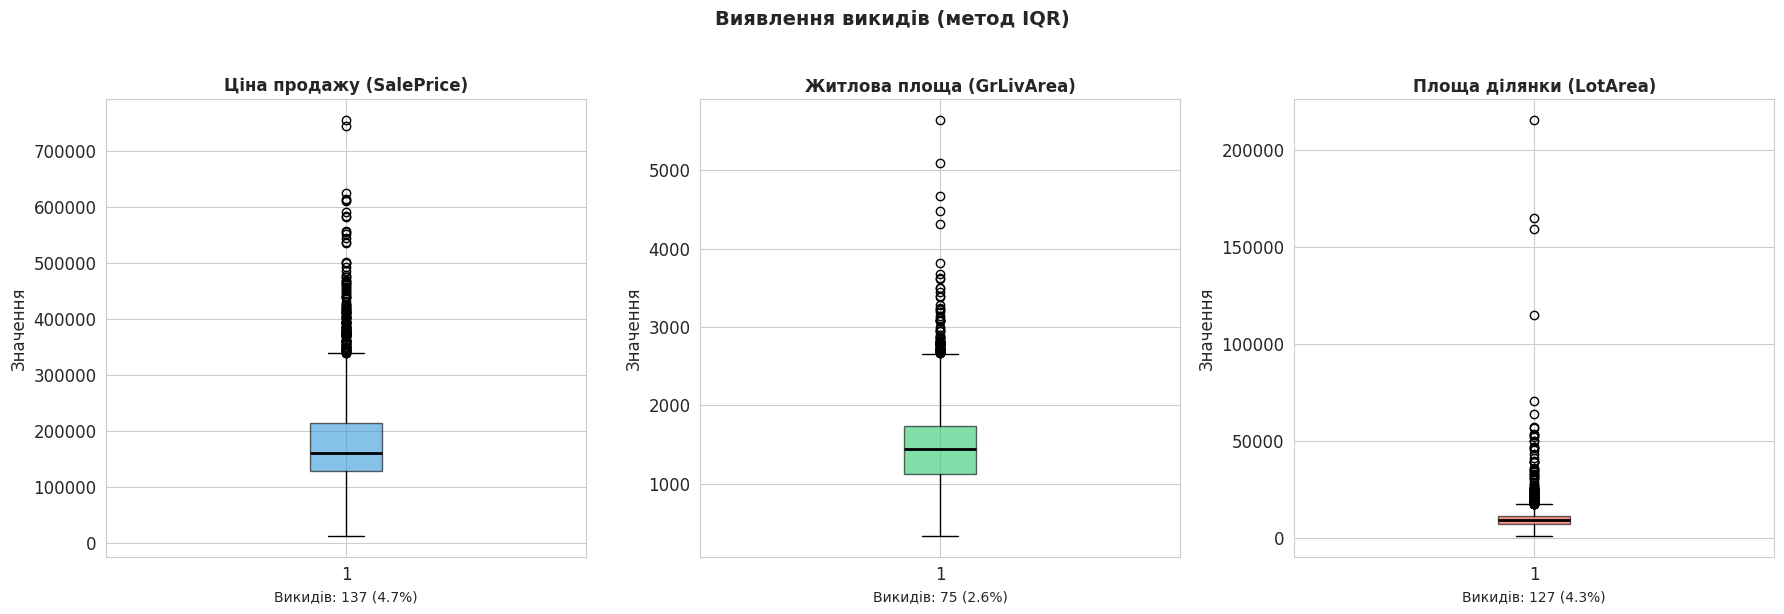

Графік збережено: boxplots_outliers.png

4.2 Метод IQR для SalePrice + стратегія обробки
Q1 = 129,500 $
Q3 = 213,500 $
IQR = 84,000 $
Нижня межа = 3,500 $
Верхня межа = 339,500 $

Виявлено викидів: 137 (4.7%)

Стратегія: Winsorization (clip до меж IQR)
  Рядків до: 2930, після: 2930 (жоден рядок не видалено)
Обґрунтування: winsorization зберігає всі спостереження, лише обрізає
  екстремальні значення — підходить для регресійних задач.


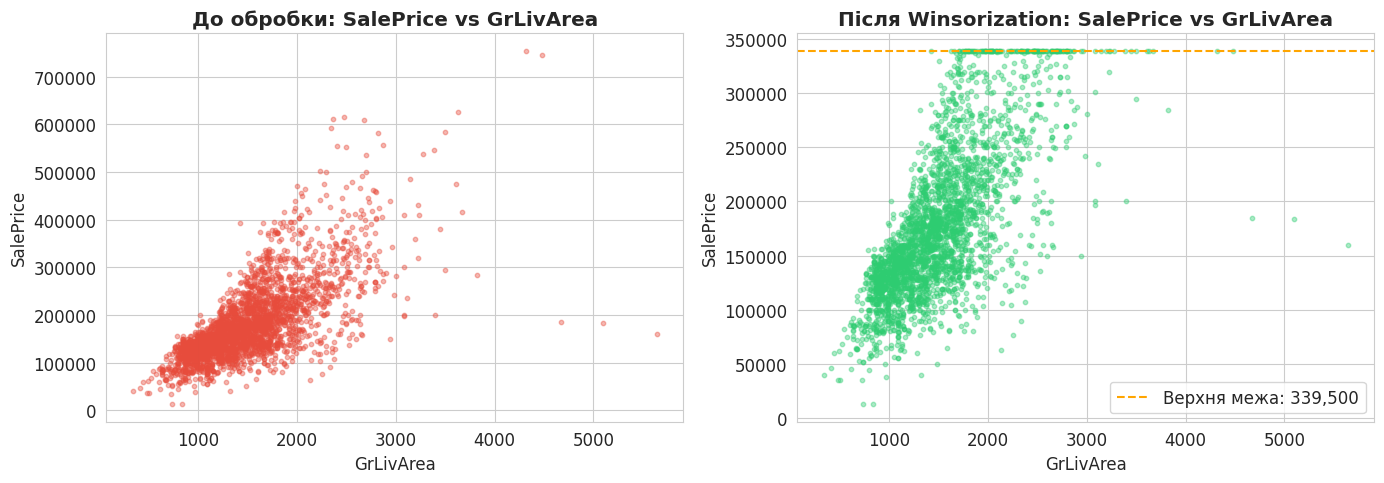

Графік збережено: outliers_before_after.png


In [25]:
# Завдання 4: Виявлення та обробка викидів

# 4.1 Побудова boxplot для трьох колонок
print("=" * 60)
print("4.1 Боксплоти для виявлення викидів")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cols_to_plot = ['SalePrice', 'GrLivArea', 'LotArea']
colors      = ['#3498db', '#2ecc71', '#e74c3c']
titles      = ['Ціна продажу (SalePrice)', 'Житлова площа (GrLivArea)', 'Площа ділянки (LotArea)']

for ax, col, color, title in zip(axes, cols_to_plot, colors, titles):
    if col in df_clean.columns:
        ax.boxplot(df_clean[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.6),
                   medianprops=dict(color='black', linewidth=2))
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel('Значення')

        # підраховуємо викиди за методом IQR (1.5 * IQR)
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1
        outliers = df_clean[(df_clean[col] < q1 - 1.5*iqr) | (df_clean[col] > q3 + 1.5*iqr)]
        ax.set_xlabel(f'Викидів: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)', fontsize=10)

plt.suptitle('Виявлення викидів (метод IQR)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=100, bbox_inches='tight')
plt.show()
print("Графік збережено: boxplots_outliers.png")

# 4.2 Метод IQR для SalePrice + стратегія Winsorization
print("\n" + "=" * 60)
print("4.2 Метод IQR для SalePrice + стратегія обробки")
print("=" * 60)

# обчислення меж за правилом IQR (стандартний коефіцієнт 1.5)
Q1  = df_clean['SalePrice'].quantile(0.25)
Q3  = df_clean['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:,.0f} $")
print(f"Q3 = {Q3:,.0f} $")
print(f"IQR = {IQR:,.0f} $")
print(f"Нижня межа = {lower_bound:,.0f} $")
print(f"Верхня межа = {upper_bound:,.0f} $")

outliers_sale = df_clean[
    (df_clean['SalePrice'] < lower_bound) | (df_clean['SalePrice'] > upper_bound)
]
print(f"\nВиявлено викидів: {len(outliers_sale)} ({len(outliers_sale)/len(df_clean)*100:.1f}%)")

# Winsorization: обрізаємо екстремальні значення до меж, не видаляємо рядки
rows_before = len(df_clean)
df_clean['SalePrice'] = df_clean['SalePrice'].clip(lower=lower_bound, upper=upper_bound)
print(f"\nСтратегія: Winsorization (clip до меж IQR)")
print(f"  Рядків до: {rows_before}, після: {len(df_clean)} (жоден рядок не видалено)")
print(f"Обґрунтування: winsorization зберігає всі спостереження, лише обрізає")
print(f"  екстремальні значення — підходить для регресійних задач.")

# scatter-графік до/після для наочного порівняння
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# до обробки — видно явні викиди у верхньому правому куті
ax1.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, color='#e74c3c', s=10)
ax1.set_title('До обробки: SalePrice vs GrLivArea', fontweight='bold')
ax1.set_xlabel('GrLivArea')
ax1.set_ylabel('SalePrice')

# після winsorization — викиди притиснуті до верхньої межі
ax2.scatter(df_clean['GrLivArea'], df_clean['SalePrice'], alpha=0.4, color='#2ecc71', s=10)
ax2.set_title('Після Winsorization: SalePrice vs GrLivArea', fontweight='bold')
ax2.set_xlabel('GrLivArea')
ax2.set_ylabel('SalePrice')
ax2.axhline(y=upper_bound, color='orange', linestyle='--',
            label=f'Верхня межа: {upper_bound:,.0f}')
ax2.legend()

plt.tight_layout()
plt.savefig('outliers_before_after.png', dpi=100, bbox_inches='tight')
plt.show()
print("Графік збережено: outliers_before_after.png")


---

## Завдання 5: Кодування та фінальна підготовка

**5.1.** Визначте, які категоріальні колонки є **порядковими** (ordinal), а які — **номінальними** (nominal).

**5.2.** Для порядкових колонок застосуйте Ordinal Encoding зі збереженням порядку.

**5.3.** Для номінальних колонок застосуйте One-Hot Encoding. Поясніть, чому Label Encoding був би некоректним для номінальних змінних.

**5.4.** Перевірте типи даних усіх колонок та виправте за потреби. Збережіть очищений датасет у файл `ames_cleaned.csv`.

**5.5.** Напишіть короткий звіт (5-7 речень): які кроки очищення ви виконали, які рішення прийняли та чому, як змінився датасет (кількість рядків, колонок, пропусків до/після).

In [26]:
# Завдання 5: Кодування та фінальна підготовка

print("=" * 60)
print("5.1 Класифікація категоріальних колонок")
print("=" * 60)

# порядкові колонки: порядок категорій від найгіршого до найкращого
ordinal_cols = {
    'BsmtQual':     ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageFinish': ['None', 'Unf', 'RFn', 'Fin'],
    'FireplaceQu':  ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Fence':        ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
    'ExterQual':    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
}

# номінальні колонки: категорії без природного порядку
nominal_cols = ['GarageType', 'MasVnrType', 'Neighborhood', 'MSZoning']

print("Порядкові (Ordinal):", list(ordinal_cols.keys()))
print("Номінальні (Nominal):", nominal_cols)

# 5.2 Ordinal Encoding зі збереженням логічного порядку
print("\n" + "=" * 60)
print("5.2 Ordinal Encoding для порядкових колонок")
print("=" * 60)

df_encoded = df_clean.copy()
for col, order in ordinal_cols.items():
    if col in df_encoded.columns:
        # будуємо словник: категорія → ціле число за позицією в списку
        mapping = {v: i for i, v in enumerate(order)}
        df_encoded[col] = df_encoded[col].map(mapping)
        print(f"  {col}: {order} → {list(range(len(order)))}")

# 5.3 One-Hot Encoding для номінальних колонок
print("\n" + "=" * 60)
print("5.3 One-Hot Encoding для номінальних колонок")
print("=" * 60)

# Label Encoding некоректний для номінальних, бо вводить хибний порядок:
# наприклад, Attchd=0, Detchd=1, BuiltIn=2 — означає нібито BuiltIn > Detchd,
# що не має сенсу. One-Hot Encoding створює окремий бінарний стовпець для кожної категорії.
print("Чому Label Encoding некоректний для номінальних:")
print("  Label Encoding присвоює цілі числа (0, 1, 2...), що вводить")
print("  хибний порядок між категоріями. Наприклад: Attchd=0, Detchd=1, BuiltIn=2")
print("  означає, що BuiltIn > Detchd — це безглуздо для номінальних ознак.")
print("  One-Hot Encoding уникає цієї проблеми, створюючи бінарні ознаки.")

df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=False, dtype=int)
new_cols = [c for c in df_encoded.columns if any(n in c for n in nominal_cols)]
print(f"\nДодано {len(new_cols)} нових колонок після OHE")
print(f"Нові колонки: {new_cols}")

# 5.4 Перевірка типів даних та збереження очищеного датасету
print("\n" + "=" * 60)
print("5.4 Перевірка типів даних та збереження")
print("=" * 60)

# конвертуємо bool → int (деякі версії pandas повертають bool після get_dummies)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Типи даних після кодування:")
print(df_encoded.dtypes.value_counts())
print(f"\nЗалишилось пропусків: {df_encoded.isnull().sum().sum()}")

# зберігаємо фінальний датасет
df_encoded.to_csv('ames_cleaned.csv', index=False)
print(f"\nДатасет збережено: ames_cleaned.csv")
print(f"Форма фінального датасету: {df_encoded.shape}")

# 5.5 Підсумковий звіт
print("\n" + "=" * 60)
print("5.5 Підсумковий звіт")
print("=" * 60)
print(f"""
Виконані кроки очищення датасету Ames Housing:

1. ДІАГНОСТИКА: датасет містив {df.shape[0]} рядків і {df.shape[1]} колонок;
   виявлено пропуски у {df.isnull().any().sum()} колонках.

2. КЛАСИФІКАЦІЯ ПРОПУСКІВ: більшість пропусків — логічні MNAR
   (NA = відсутність об'єкта: гараж, камін, підвал, паркан);
   LotFrontage класифіковано як MAR через залежність від Neighborhood.

3. ІМПУТАЦІЯ: логічні NA у категоріальних замінені на 'None', числові — на 0;
   LotFrontage заповнено медіаною по районах (MAR-стратегія).

4. ВИКИДИ: виявлено методом IQR; для SalePrice застосовано Winsorization —
   збережено всі рядки, а екстремальні значення обрізані до меж [Q1−1.5·IQR, Q3+1.5·IQR].

5. КОДУВАННЯ: порядкові колонки (BsmtQual, GarageFinish, FireplaceQu, Fence, ExterQual)
   закодовано Ordinal Encoding зі збереженням логічного порядку;
   номінальні (GarageType, MasVnrType, Neighborhood, MSZoning) — One-Hot Encoding.

Результат: {df.shape[0]} рядків збережено (видалення не застосовувалось),
кількість колонок зросла з {df.shape[1]} до {df_encoded.shape[1]} через OHE,
кількість пропусків: {df.isnull().sum().sum()} → 0.
""")


5.1 Класифікація категоріальних колонок
Порядкові (Ordinal): ['BsmtQual', 'GarageFinish', 'FireplaceQu', 'Fence', 'ExterQual']
Номінальні (Nominal): ['GarageType', 'MasVnrType', 'Neighborhood', 'MSZoning']

5.2 Ordinal Encoding для порядкових колонок
  BsmtQual: ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'] → [0, 1, 2, 3, 4, 5]
  GarageFinish: ['None', 'Unf', 'RFn', 'Fin'] → [0, 1, 2, 3]
  FireplaceQu: ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'] → [0, 1, 2, 3, 4, 5]
  Fence: ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'] → [0, 1, 2, 3, 4]
  ExterQual: ['Po', 'Fa', 'TA', 'Gd', 'Ex'] → [0, 1, 2, 3, 4]

5.3 One-Hot Encoding для номінальних колонок
Чому Label Encoding некоректний для номінальних:
  Label Encoding присвоює цілі числа (0, 1, 2...), що вводить
  хибний порядок між категоріями. Наприклад: Attchd=0, Detchd=1, BuiltIn=2
  означає, що BuiltIn > Detchd — це безглуздо для номінальних ознак.
  One-Hot Encoding уникає цієї проблеми, створюючи бінарні ознаки.

Додано 47 нових колонок після OHE
Нові к

Висновок: У ході виконання лабораторної роботи було проаналізовано пропущені значення в наборі даних та визначено механізми їх виникнення: частина з них відноситься до MAR (наприклад, LotFrontage, де пропуски залежать від району), а частина — до MNAR, що мають логічний зміст і означають відсутність об’єкта (гараж, камін, паркан тощо). Відповідно до цього було обрано обґрунтовані стратегії імпутації: для категоріальних ознак пропуски замінено на значення "None", для числових — на 0, а для LotFrontage використано медіану в межах кожного району (Neighborhood), що дозволило врахувати локальні особливості даних. У результаті всі пропущені значення були успішно оброблені, а дані стали більш узгодженими та придатними для подальшого аналізу і моделювання, що підтверджує важливість правильного вибору методів обробки залежно від природи пропусків.